# Follow the Industry: Data Preparation

This notebook loads OpenSecrets bulk data (PAC contributions to U.S. federal candidates) and builds a bipartite **Industry to Legislator** network to be used for network analysis.

**Inputs** (placed in `./data/`):
- `cands22.txt`, `cmtes22.txt`, `pacs22.txt`                     -> OpenSecrets 2022 cycle bulk data
- `cands20.txt`, `cmtes20.txt`, `pacs20.txt`                     -> 2020 cycle (potentially used for analysis over time)
- `CRP_Categories.txt`                                           -> industry-code lookup
- `legislators-current.yaml`, `legislators-historical.yaml`      -> clean legislator metadata
- `committee-membership-current.yaml`, `committees-current.yaml` -> committee assignments
- `HS117_members.csv`                                            -> Voteview  ideology scores for the 117th Congress

**Outputs**:
- `lobbying_bipartite.gexf`   -> weighted bipartite graph (industries ↔ legislators)
- `lobbying_legislators.gexf` -> legislator-side projection
- `lobbying_industries.gexf`  -> industry-side projection

The **2022 cycle data** is used as the primary network because it captures fundraising during the 117th Congress's tenure. The 2020 cycle is also loaded with the intention that it will be used later for comparison across time.

In [3]:
# Setup
%pip install -q networkx pandas matplotlib numpy scipy pyyaml powerlaw

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import yaml
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import bipartite

from helpers import (
    get_average_degree, get_kmax, get_kmin, make_degree_histogram, size_of_giant_component, fast_bipartite_projection
)

np.random.seed(0)
plt.style.use('ggplot')
DATA_DIR = "data"

## 1. Load OpenSecrets bulk files

The OpenSecrets bulk format is **pipe-quoted, comma-separated, no header** (every text field is wrapped in `|...|`). Column names come from the OpenSecrets User's Guide and are supplied explicitly.

In [11]:
CANDS_COLS = ['Cycle', 'FECCandID', 'CID', 'FirstLastP', 'Party', 'DistIDRunFor',
              'DistIDCurr','CurrCand','CycleCand', 'CRPICO','RecipCode','NoPacs']

CMTES_COLS = ['Cycle','CmteID','PACShort','Affiliate','UltOrg', 'RecipID','RecipCode',
              'FECCandID','Party','PrimCode', 'Source','Sensitive','Foreign','Active']

PACS_COLS = ['Cycle', 'FECRecNo','PACID','CID','Amount','Date', 'RealCode','Type','DI',
             'FECCandID']

def load_opensecrets(cycle="22"):
    cands = pd.read_csv(os.path.join(DATA_DIR, f"cands{cycle}.txt"), sep=',', quotechar='|',
                        header=None, names=CANDS_COLS, dtype=str, on_bad_lines='warn')
    cmtes = pd.read_csv(os.path.join(DATA_DIR, f"cmtes{cycle}.txt"), sep=',', quotechar='|',
                        header=None, names=CMTES_COLS, dtype=str, on_bad_lines='warn')
    pacs = pd.read_csv(os.path.join(DATA_DIR, f"pacs{cycle}.txt"), sep=',', quotechar='|',
                        header=None, names=PACS_COLS, dtype=str, on_bad_lines='warn')
    
    return cands, cmtes, pacs
    
cands, cmtes, pacs = load_opensecrets()
print(f"cands22.txt: {len(cands):>7,} rows")
print(f"cmtes22.txt: {len(cmtes):>7,} rows")
print(f"pacs22.txt: {len(pacs):>7,} rows")

cands22.txt:   8,928 rows
cmtes22.txt:  19,788 rows
pacs22.txt: 758,125 rows


## 2. Apply OpenSecrets User's Guide filters

Per the OpenSecrets User's Guide, two filters must be applied to the PAC-to-candidate table before any analysis:

1. **Drop transfers and joint-fundraising committees**:
   `RealCode NOT LIKE 'Z9*' AND RealCode NOT LIKE 'Z4*'`
2. **Keep only direct contributions**: `DI = 'D'`

Also, drop **negative amounts** (refunds) and **zero-dollar** records. These three filters together remove roughly 70% of the raw rows but the remaining transactions are the only ones that legitimately represent industry to legislator money flow.

In [12]:
# Cast amount to numeric and normalize codes
pacs['Amount'] = pd.to_numeric(pacs['Amount'], errors='coerce')
pacs['RealCode'] = pacs['RealCode'].str.upper().str.strip()
pacs['DI'] = pacs['DI'].str.upper().str.strip()

n_raw = len(pacs)

# Filer 1: drop Z9* (transfers) and Z4* (joint fundraising committees)
filter_1 = ~pacs['RealCode'].str.startswith(('Z9', 'Z4'), na=False)

# Filer 2: keep DI = 'D' (direct contributions)
filter_2 = pacs['DI'] == 'D'

# Fileter 3: Only select positive ammounts (drops refunds and 0's)
filter_3 = pacs['Amount'].fillna(0) > 0

# Stack filters and copy
pacs_cleaned = pacs[filter_1 & filter_2 & filter_3].copy()

# Print
print(f"Filter process outline:")
print(f"   unfiltered rows:               {n_raw:>9,}")
print(f"   after Filter 1:                {filter_1.sum():>9,}")
print(f"   after Filter 2:                {(filter_1 & filter_2).sum():>9,}")
print(f"   after Filter 3:                {len(pacs_cleaned):>9,}")
print(f"   rows eliminated by filtering:  {n_raw - len(pacs_cleaned):>9,}")
print(f"   percent eliminated:            {n_raw - len(pacs_cleaned):>9,}  ({100*(n_raw-len(pacs_cleaned))/n_raw:.1f}%)")
print(f"\n TOTAL DOLLAR AMOUNT SPENT: ${pacs_cleaned['Amount'].sum():,.2f}")

Filter process outline:
   unfiltered rows:                 758,125
   after Filter 1:                  318,711
   after Filter 2:                  236,980
   after Filter 3:                  228,884
   rows eliminated by filtering:    529,241
   percent eliminated:              529,241  (69.8%)

 TOTAL DOLLAR AMOUNT SPENT: $500,072,213.00


## 3. Join to industry and sector lookup

Each PAC has a `PrimCode` (in `cmtes22.txt`) and each contribution has a `RealCode` (the industry code OpenSecrets actually classifies that specific transaction with). The two are usually identical, but `RealCode` can differ when a contribution was reclassified individually.

I used `RealCode` from the contribution and looked up the `Industry` and `Sector` names via `CRP_Categories.txt`.

In [13]:
# CRP_Categories.txt has a 7-line header with licenesing data, then a tab seperated table
categories = pd.read_csv(os.path.join(DATA_DIR, "CRP_Categories.txt"), sep='\t',
                         skiprows=7, dtype=str)
categories = categories.rename(columns={'Sector Long': 'SectorLong'})
print(f"Loaded {len(categories)} industry codes and {categories['Sector'].nunique()} sectors")
print(f"Top-level sectors: ", sorted(categories['Sector'].dropna().unique()))
print("\n")
categories.head()

Loaded 485 industry codes and 15 sectors
Top-level sectors:  ['Agribusiness', 'Communic/Electronics', 'Construction', 'Defense', 'Energy/Nat Resource', 'Finance/Insur/RealEst', 'Health', 'Ideology/Single-Issue', 'Labor', 'Lawyers & Lobbyists', 'Misc Business', 'Other', 'Party/Non-contribs', 'Transportation', 'Unknown']




,Catcode,Catname,Catorder,Industry,Sector,SectorLong
0,A0000,Agriculture,A11,Misc Agriculture,Agribusiness,Agribusiness
1,A1000,Crop production & basic processing,A01,Crop Production & Basic Processing,Agribusiness,Agribusiness
2,A1100,Cotton,A01,Crop Production & Basic Processing,Agribusiness,Agribusiness
3,A1200,Sugar cane & sugar beets,A01,Crop Production & Basic Processing,Agribusiness,Agribusiness
4,A1300,Tobacco & Tobacco products,A02,Tobacco,Agribusiness,Agribusiness


In [17]:
# Merge contributions with industy and sector
pacs_industry = pacs_cleaned.merge(
    categories[['Catcode', 'Catname', 'Industry', 'Sector']],
    left_on='RealCode', right_on='Catcode', how='left'
)

# Check if the merge worked, should be no contributions without an industry code
unmatched = pacs_industry['Sector'].isna().sum()
print(f"Contributions with no industry code: {unmatched:,}  ({100*unmatched/len(pacs_industry):.1f}%)")
print(f"Most common unmatched RealCodes:")
print(pacs_industry[pacs_industry['Sector'].isna()]['RealCode'].value_counts().head(5))

# Drop any unmatched contributions from previous check
pacs_industry = pacs_industry.dropna(subset=['Sector']).copy()

# Finally, filer "Party/Non-contributions" Sector
# These are placeholder transactions between the party & committee, or campaign self-finance
# contributions not typically associated with "industry lobbying"
o_n_value = len(pacs_industry)
pacs_industry = pacs_industry[pacs_industry['Sector'] != 'Party/Non-contribs'].copy()
print(f"\nDropped {o_n_value - len(pacs_industry):,} Party/Non-Contribution transactions.")
print(f"Final cleaned contributions: {len(pacs_industry):,}")
print(f"FINAL TOTAL LOBBYING DOLAR VALUE: s{pacs_industry['Amount'].sum():,.2f}")

Contributions with no industry code: 0  (0.0%)
Most common unmatched RealCodes:
Series([], Name: count, dtype: int64)

Dropped 1,279 Party/Non-Contribution transactions.
Final cleaned contributions: 227,605
FINAL TOTAL LOBBYING DOLAR VALUE: s496,536,102.00


## 4. Create (industry, legislator) edges

Collapse multiple transactions from a single industry to the same legislator into a single weighted edge. 
I used the **industry** level (finer-grained than sector) as the node type, with the parent **sector** preserved as a node attribute.
First 5 rows of edges are printed as an example. 

In [18]:
edges = (
    pacs_industry.groupby(
        ['Catcode','Catname','Industry','Sector','CID'], 
        as_index=False).agg(
            amount=('Amount','sum'), 
            n_contribs=('Amount','size'), 
            n_pacs=('PACID','nunique'))
)

print(f"Bipartite edges: {len(edges):,}")
print(f"Distinct industries: {edges['Catcode'].nunique()}")
print(f"Distinct legislators: {edges['CID'].nunique()}")
edges.head()

Bipartite edges: 54,999
Distinct industries: 391
Distinct legislators: 1493


,Catcode,Catname,Industry,Sector,CID,amount,n_contribs,n_pacs
0,A0000,Agriculture,Misc Agriculture,Agribusiness,N00002674,2500,1,1
1,A0000,Agriculture,Misc Agriculture,Agribusiness,N00002893,2000,1,1
2,A0000,Agriculture,Misc Agriculture,Agribusiness,N00004118,2500,1,1
3,A0000,Agriculture,Misc Agriculture,Agribusiness,N00004572,1000,1,1
4,A0000,Agriculture,Misc Agriculture,Agribusiness,N00005559,2500,1,1


## 5. Enrich legislators with metadata (YAML + Voteview)

The OpenSecrets `cands22.txt` has only minimal legislator info. I will enrich each legislator node with data from three additional sources:

- **`legislators-current.yaml`** + **`legislators-historical.yaml`** —
  clean party, chamber, state, gender, birthdate, and crucially the `bioguide_id` (Library of Congress ID) which links to other the other datasets used.

- **`HS117_members.csv`** (Voteview) - Ideology score (`nominate_dim1`: -1 = liberal, +1 = conservative).

- **`committee-membership-current.yaml`** — committee assignments, enables me to ask whether industries cluster around specific committees.

I expected this to take a long time, but TG for gaming laptops. 

In [19]:
# Build CRP-ID -> {bioguide, party, chamber, state, gender} from YAMLs
def index_legislators(yaml_paths):
    # Returns a dictionary keyed by OpenSecrets CID with bioguide + most-recent term (117) info.
    output = {}
    for path in yaml_paths:
        with open(path) as f:
            recs = yaml.safe_load(f)
        for rec in recs:
            crp = rec.get('id', {}).get('opensecrets')
            if not crp:
                continue
            terms = rec.get('terms', [])
            if not terms:
                continue
            # Prefer most recent term
            term = terms[-1]
            output[crp] = {
                'bioguide_id': rec.get('id', {}).get('bioguide'),
                'icpsr':       rec.get('id', {}).get('icpsr'),
                'first':       rec.get('name', {}).get('first', ''),
                'last':        rec.get('name', {}).get('last', ''),
                'gender':      rec.get('bio', {}).get('gender', ''),
                'birthday':    rec.get('bio', {}).get('birthday', ''),
                'chamber':     'S' if term.get('type') == 'sen' else 'H',
                'state':       term.get('state', ''),
                'party_yaml':  term.get('party', ''),
            }
    return output

leg_meta = index_legislators([
    os.path.join(DATA_DIR, "legislators-current.yaml"),
    os.path.join(DATA_DIR, "legislators-historical.yaml"),
])
print(f"Indexed {len(leg_meta):,} legislators by CRP id (current + historical)")

Indexed 1,442 legislators by CRP id (current + historical)


In [25]:
# Attribute Voteview ideology scores to legislators. 
vote = pd.read_csv(os.path.join(DATA_DIR, "HS117_members.csv"))

# Keep only members of Congress (drop the President/VP rows)
vote = vote[vote['chamber'].isin(['House','Senate'])].copy()
ideology = vote.set_index('bioguide_id')[['nominate_dim1','nominate_dim2']].to_dict('index')

print(f"Loaded ideology scores for {len(ideology):,} 117th Congress members")

Loaded ideology scores for 557 117th Congress members


In [22]:
# Attribute committee assignments to legislators
with open(os.path.join(DATA_DIR, "committee-membership-current.yaml")) as f:
    comm_mem = yaml.safe_load(f)

# Invert: bioguide_id -> list of committee thomas_ids
bioguide_to_committees = {}
for committee_id, members in comm_mem.items():
    if not isinstance(members, list):
        continue
    for member in members:
        bid = member.get('bioguide')
        if bid:
            bioguide_to_committees.setdefault(bid, []).append(committee_id)

print(f"Indexed committee membership for {len(bioguide_to_committees):,} legislators")
print(f"Distinct committees: {len(comm_mem):,}")

Indexed committee membership for 528 legislators
Distinct committees: 230


In [26]:
# Assemble enriched legislator records used for graph node attributes
enriched_legs = {}
for cid, row in cands.set_index('CID').iterrows():
    meta = leg_meta.get(cid, {})
    bid = meta.get('bioguide_id')
    ideo = ideology.get(bid, {}) if bid else {}
    enriched_legs[cid] = {
        'name'      : row['FirstLastP'],
        'party'     : row['Party'],
        'dist'      : row['DistIDRunFor'],
        'bioguide'  : bid or '',
        'chamber'   : meta.get('chamber', ''),
        'state'     : meta.get('state',   ''),
        'gender'    : meta.get('gender',  ''),
        'ideology'  : ideo.get('nominate_dim1', np.nan),
        'committees': ';'.join(bioguide_to_committees.get(bid, [])) if bid else '',
        'n_committees': len(bioguide_to_committees.get(bid, [])) if bid else 0,
    }

# Coverage diagnostics
n_total       = len(enriched_legs)
n_with_bio    = sum(1 for v in enriched_legs.values() if v['bioguide'])
n_with_ideo   = sum(1 for v in enriched_legs.values() if not pd.isna(v['ideology']))
n_with_comm   = sum(1 for v in enriched_legs.values() if v['n_committees'] > 0)
print(f"Total candidates from cands22 : {n_total:,}")
print(f"  with bioguide id            : {n_with_bio:,}  ({100*n_with_bio/n_total:.1f}%)")
print(f"  with Voteview ideology      : {n_with_ideo:,}  ({100*n_with_ideo/n_total:.1f}%)")
print(f"  with committee assignments  : {n_with_comm:,}  ({100*n_with_comm/n_total:.1f}%)")

Total candidates from cands22 : 8,293
  with bioguide id            : 906  (10.9%)
  with Voteview ideology      : 557  (6.7%)
  with committee assignments  : 458  (5.5%)


## 6. Build the bipartite graph

- **Industry nodes**: `bipartite=0`, type `'industry'`, with sector parent.

- **Legislator nodes**: `bipartite=1`, type `'legislator'`, enriched with party, chamber, state, ideology, and committee count.

- **Edges**: weighted by total contribution dollars.

In [27]:
B = nx.Graph()

# Industry nodes
for code, group in categories.dropna(subset=['Sector']).groupby('Catcode'):
    row = group.iloc[0]
    sid = f"IND::{code}"
    B.add_node(sid,
               bipartite=0,
               type="industry",
               label=row['Catname'],
               ind_code=code,
               industry=row['Industry'],
               sector=row['Sector'])

# Legislator nodes
for cid, info in enriched_legs.items():
    lid = f"LEG::{cid}"
    B.add_node(lid,
               bipartite=1,
               type="legislator",
               label=info['name'],
               party=info['party'],
               chamber=info['chamber'],
               state=info['state'],
               gender=info['gender'],
               bioguide=info['bioguide'],
               ideology=info['ideology'] if not pd.isna(info['ideology']) else 0.0,
               has_ideology=int(not pd.isna(info['ideology'])),
               n_committees=info['n_committees'])

# Edges
edge_dropped = 0
for _, row in edges.iterrows():
    sid = f"IND::{row['Catcode']}"
    lid = f"LEG::{row['CID']}"
    if sid in B.nodes and lid in B.nodes:
        B.add_edge(sid, lid,
                   weight=float(row['amount']),
                   n_contribs=int(row['n_contribs']),
                   n_pacs=int(row['n_pacs']))
    else:
        edge_dropped += 1

industries  = {n for n,d in B.nodes(data=True) if d['type']=='industry'}
legislators = {n for n,d in B.nodes(data=True) if d['type']=='legislator'}

print(f"Bipartite graph B: {B.number_of_nodes():,} nodes, {B.number_of_edges():,} edges")
print(f"  Industries  : {len(industries):,}")
print(f"  Legislators : {len(legislators):,}")
print(f"  Is bipartite: {bipartite.is_bipartite(B)}")
print(f"  Avg degree  : {get_average_degree(B):.2f}")
print(f"  Edges dropped (orphan endpoints): {edge_dropped}")

Bipartite graph B: 8,778 nodes, 54,992 edges
  Industries  : 485
  Legislators : 8,293
  Is bipartite: True
  Avg degree  : 12.53
  Edges dropped (orphan endpoints): 7


## 7. Build the giant component

Many candidates listed in `cands22.txt` were either minor or unsuccessful at fundraising, and received zero PAC money. Likewise some industry codes contribuuted $0 in this cycle. Building a giant component removes these non-contributors.

In [28]:
def giant(g):
    return g.subgraph(max(nx.connected_components(g), key=len)).copy()

B_full = B.copy()
B = giant(B)

industries  = {n for n,d in B.nodes(data=True) if d['type']=='industry'}
legislators = {n for n,d in B.nodes(data=True) if d['type']=='legislator'}

print(f"Giant component:")
print(f"  Nodes : {B.number_of_nodes():,}  (was {B_full.number_of_nodes():,})")
print(f"  Edges : {B.number_of_edges():,}")
print(f"  Industries : {len(industries):,}")
print(f"  Legislators: {len(legislators):,}")

Giant component:
  Nodes : 1,875  (was 8,778)
  Edges : 54,991
  Industries : 390
  Legislators: 1,485


## 8. Build single-mode projections

- **Legislator projection `L`**: legislators are connected if they share at least one industry funder. Edge weight = number of shared industries.

- **Industry projection `I`**: industries are connected if they fund at least one shared legislator. Edge weight = number of shared legislators.

My first attempt was very dense (bipartite projections are notorious for this). So, I threshold each by edge weight so only meaningful structural ties survive.

In [29]:
# Fast sparse projections had to be developed, since NetworkX's projections are too slow at this
# size. fast_bipartite_projection uses scipy sparse matrix multiplication: A @ A.T where A is the 
# bipartite adjacency. Equivalent result, ~100x faster.

L_full = fast_bipartite_projection(B, legislators, threshold_percentile=None)
I_full = fast_bipartite_projection(B, industries,  threshold_percentile=None)

print(f"Raw projections:")
print(f"  L: {L_full.number_of_nodes():,} nodes, {L_full.number_of_edges():,} edges, density {nx.density(L_full):.3f}")
print(f"  I: {I_full.number_of_nodes():,} nodes, {I_full.number_of_edges():,} edges, density {nx.density(I_full):.3f}")

# Threshold to keep only the strongest co-funding ties
L = fast_bipartite_projection(B, legislators, threshold_percentile=90)
I = fast_bipartite_projection(B, industries,  threshold_percentile=80)

# Restrict to giant components after thresholding
L = giant(L)
I = giant(I)

print(f"\nAfter threshold + giant component:")
print(f"  L: {L.number_of_nodes():,} nodes, {L.number_of_edges():,} edges, density {nx.density(L):.3f}")
print(f"     <k>={get_average_degree(L):.2f}")
print(f"  I: {I.number_of_nodes():,} nodes, {I.number_of_edges():,} edges, density {nx.density(I):.3f}")
print(f"     <k>={get_average_degree(I):.2f}")

Raw projections:
  L: 1,485 nodes, 619,709 edges, density 0.562
  I: 390 nodes, 66,386 edges, density 0.875

After threshold + giant component:
  L: 499 nodes, 63,303 edges, density 0.509
     <k>=253.72
  I: 226 nodes, 13,469 edges, density 0.530
     <k>=119.19


## 9. Check degree distributions

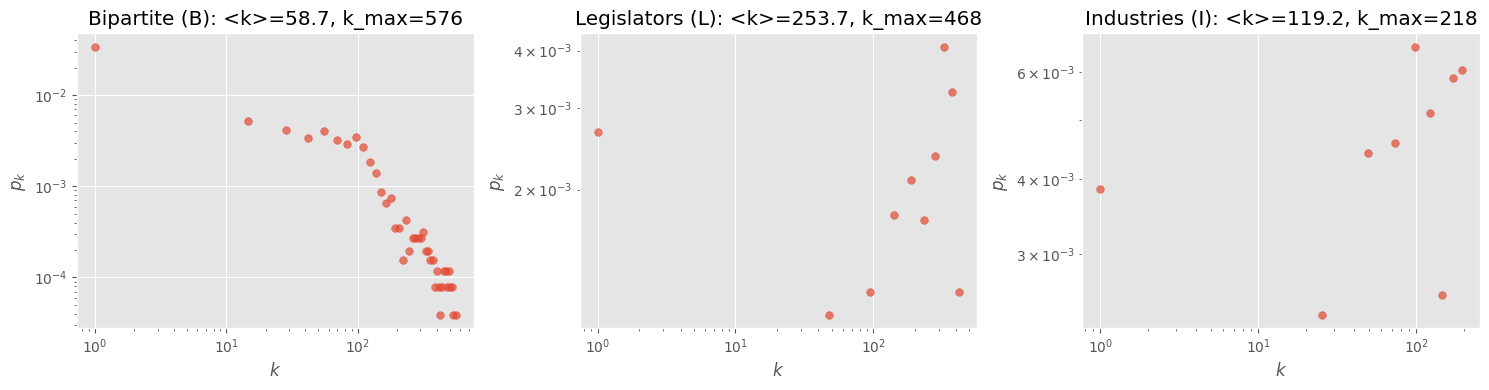

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, g, name in zip(axes, [B, L, I], ['Bipartite (B)', 'Legislators (L)', 'Industries (I)']):
    k, pk = make_degree_histogram(g, bins='auto')
    ax.scatter(k, pk, s=30, alpha=0.7)
    ax.set_xlabel('$k$'); ax.set_ylabel('$p_k$')
    ax.set_title(f"{name}: <k>={get_average_degree(g):.1f}, k_max={get_kmax(g)}")
    ax.set_yscale('log'); ax.set_xscale('log')
plt.tight_layout(); plt.show()

## 10. Save graphs

GEXF preserves all node and edge attributes. These three files wil be the inputs to `analysis.ipynb` and to Gephi (for better visualizations).

In [31]:
# GEXF doesn't accept NaN, therefore, coerce any remaining floats
for g in (B, L, I):
    for n, d in g.nodes(data=True):
        for k, v in list(d.items()):
            if isinstance(v, float) and np.isnan(v):
                d[k] = 0.0

nx.write_gexf(B, "lobbying_bipartite.gexf")
nx.write_gexf(L, "lobbying_legislators.gexf")
nx.write_gexf(I, "lobbying_industries.gexf")
print("Saved:")
print("  lobbying_bipartite.gexf")
print("  lobbying_legislators.gexf")
print("  lobbying_industries.gexf")


Saved:
  lobbying_bipartite.gexf
  lobbying_legislators.gexf
  lobbying_industries.gexf
